# Pretrained_Model_Classification

```css
1. VGGNET
2. ResNET
3. Xception
4. MobileNET
5. ConvNeT

```

# Import Libraries

In [28]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [29]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import VGG19, ResNet50, Xception, MobileNet, ConvNeXtXLarge

from tensorflow.keras.applications.vgg19 import preprocess_input, decode_predictions
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.applications.xception import preprocess_input, decode_predictions
from tensorflow.keras.applications.mobilenet import preprocess_input, decode_predictions
from tensorflow.keras.applications.convnext import preprocess_input, decode_predictions

# Import Image

In [72]:
def load_image(img_path: str, image_size: tuple, dim=1):
  img = image.load_img(img_path, target_size=image_size)
  x = image.img_to_array(img)

  if dim == 1:
    x = np.expand_dims(x, axis=0)
  else:
    x = np.expand_dims(x, axis=0)
    x = np.vstack([x])
  x = preprocess_input(x)
  return x, img

In [73]:
samsung_x, samsung_image = load_image('samsung.webp', (224, 224))
cactus_x, cactus_image = load_image('cactus.webp', (224, 224))
litchi_x, litchi_image = load_image('litchi.jpg', (224, 224))
rongon_x, rongon_image = load_image('rongon.webp', (224, 224))
processor_x, processor_image = load_image('ryzen.jpeg', (224, 224))

In [70]:
display(samsung_x.shape)

(1, 224, 224, 3)

# Image Show

Text(0.5, 1.0, 'Processor')

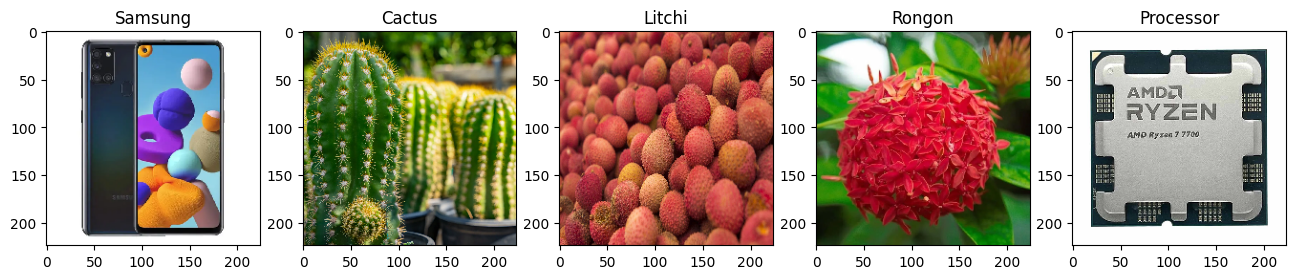

In [71]:
plt.figure(figsize=(16, 10))
plt.subplot(1, 5, 1)

plt.imshow(samsung_image)
plt.title('Samsung')

plt.subplot(1, 5, 2)
plt.imshow(cactus_image)
plt.title('Cactus')

plt.subplot(1, 5, 3)
plt.imshow(litchi_image)
plt.title('Litchi')

plt.subplot(1, 5, 4)
plt.imshow(rongon_image)
plt.title('Rongon')

plt.subplot(1, 5, 5)
plt.imshow(processor_image)
plt.title('Processor')

# `VGGNET`

## Load-Preprocess inage

In [74]:
samsung_x, samsung_image = load_image('samsung.webp', (224, 224))
cactus_x, cactus_image = load_image('cactus.webp', (224, 224))
litchi_x, litchi_image = load_image('litchi.jpg', (224, 224))
rongon_x, rongon_image = load_image('rongon.webp', (224, 224))
processor_x, processor_image = load_image('ryzen.jpeg', (224, 224))

In [33]:
vggnet = VGG19(weights='imagenet')
vggnet.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,31

 Total params: 143,667,240 (548.05 MB)

 Trainable params: 143,667,240 (548.05 MB)

 Non-trainable params: 0 (0.00 B)

## Predict

In [77]:
s_pred = vggnet.predict(samsung_x)
c_pred = vggnet.predict(cactus_x)
l_pred = vggnet.predict(litchi_x)
r_pred = vggnet.predict(rongon_x)
p_pred = vggnet.predict(processor_x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


## Decode Prediction

In [76]:
print(f'Samsung Prediction {decode_predictions(s_pred, top=3)}')
print(f'Cactus Prediction {decode_predictions(c_pred, top=3)}')
print(f'Litchi Prediction {decode_predictions(l_pred, top=3)}')
print(f'Rongon Prediction {decode_predictions(r_pred, top=3)}')
print(f'Processor Prediction {decode_predictions(p_pred, top=3)}')

Samsung Prediction [[('n03666591', 'lighter', np.float32(0.44672912)), ('n03584254', 'iPod', np.float32(0.42902562)), ('n04074963', 'remote_control', np.float32(0.026359066))]]
Cactus Prediction [[('n02869837', 'bonnet', np.float32(0.10371179)), ('n03991062', 'pot', np.float32(0.0870353)), ('n11939491', 'daisy', np.float32(0.08512403))]]
Litchi Prediction [[('n01914609', 'sea_anemone', np.float32(0.32275197)), ('n11939491', 'daisy', np.float32(0.25940898)), ('n09256479', 'coral_reef', np.float32(0.076641746))]]
Rongon Prediction [[('n07730033', 'cardoon', np.float32(0.21771345)), ('n07718747', 'artichoke', np.float32(0.14017159)), ('n02206856', 'bee', np.float32(0.116688974))]]
Processor Prediction [[('n02916936', 'bulletproof_vest', np.float32(0.2866279)), ('n03291819', 'envelope', np.float32(0.21003227)), ('n03492542', 'hard_disc', np.float32(0.096826866))]]


# ResNET

## Load  Data

In [88]:
image_size = (224, 224)
samsung_x, samsung_image = load_image('samsung.webp', image_size=image_size)
cactus_x, cactus_image = load_image('cactus.webp', image_size=image_size)
litchi_x, litchi_image = load_image('litchi.jpg', image_size=image_size)
rongon_x, rongon_image = load_image('rongon.webp', image_size=image_size)
processor_x, processor_image = load_image('ryzen.jpeg', image_size=image_size)

In [89]:
resnet = ResNet50(weights='imagenet')
resnet.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_8[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

## Predict

In [90]:
s_pre2 = resnet.predict(samsung_x)
c_pre2 = resnet.predict(cactus_x)
l_pre2 = resnet.predict(litchi_x)
r_pre2 = resnet.predict(rongon_x)
p_pre2 = resnet.predict(processor_x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


## Decode Prediction

In [91]:
print(f'Samsung Prediction {decode_predictions(s_pre2, top=3)}')
print(f'Cactus Prediction {decode_predictions(c_pre2, top=3)}')
print(f'Litchi Prediction {decode_predictions(l_pre2, top=3)}')
print(f'Rongon Prediction {decode_predictions(r_pre2, top=3)}')
print(f'Processor Prediction {decode_predictions(p_pre2, top=3)}')

Samsung Prediction [[('n06359193', 'web_site', np.float32(0.96150464)), ('n04074963', 'remote_control', np.float32(0.010446952)), ('n03180011', 'desktop_computer', np.float32(0.004631021))]]
Cactus Prediction [[('n03991062', 'pot', np.float32(0.32190418)), ('n03196217', 'digital_clock', np.float32(0.21504141)), ('n04275548', 'spider_web', np.float32(0.09083379))]]
Litchi Prediction [[('n03729826', 'matchstick', np.float32(0.65121776)), ('n03445777', 'golf_ball', np.float32(0.16606931)), ('n03250847', 'drumstick', np.float32(0.02676274))]]
Rongon Prediction [[('n02219486', 'ant', np.float32(0.15899768)), ('n02206856', 'bee', np.float32(0.11957778)), ('n02190166', 'fly', np.float32(0.06780738))]]
Processor Prediction [[('n06359193', 'web_site', np.float32(0.5911473)), ('n03481172', 'hammer', np.float32(0.18230538)), ('n03498962', 'hatchet', np.float32(0.054625776))]]


# Xception

## Load Data

In [92]:
image_size = (299, 299)
samsung_x, samsung_image = load_image('samsung.webp', image_size=image_size)
cactus_x, cactus_image = load_image('cactus.webp', image_size=image_size)
litchi_x, litchi_image = load_image('litchi.jpg', image_size=image_size)
rongon_x, rongon_image = load_image('rongon.webp', image_size=image_size)
processor_x, processor_image = load_image('ryzen.jpeg', image_size=image_size)

In [93]:
xception_model = Xception(weights='imagenet')
xception_model.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer_9[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 74, 74,    │        512 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add_24[0][0]    

 Total params: 22,910,480 (87.40 MB)

 Trainable params: 22,855,952 (87.19 MB)

 Non-trainable params: 54,528 (213.00 KB)

## Predict

In [94]:
s_pred3 = xception_model.predict(samsung_x)
c_pred3 = xception_model.predict(cactus_x)
l_pred3 = xception_model.predict(litchi_x)
r_pred3 = xception_model.predict(rongon_x)
p_pred3 = xception_model.predict(processor_x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step


## Decode Prediction

In [95]:
print(f'Samsung Prediction {decode_predictions(s_pred3, top=3)}')
print(f'Cactus Prediction {decode_predictions(c_pred3, top=3)}')
print(f'Litchi Prediction {decode_predictions(l_pred3, top=3)}')
print(f'Rongon Prediction {decode_predictions(r_pred3, top=3)}')
print(f'Processor Prediction {decode_predictions(p_pred3, top=3)}')

Samsung Prediction [[('n03775546', 'mixing_bowl', np.float32(1.0)), ('n03908618', 'pencil_box', np.float32(2.75469e-09)), ('n03908714', 'pencil_sharpener', np.float32(1.522701e-09))]]
Cactus Prediction [[('n03942813', 'ping-pong_ball', np.float32(0.84908265)), ('n03814906', 'necklace', np.float32(0.14297831)), ('n04252077', 'snowmobile', np.float32(0.003627115))]]
Litchi Prediction [[('n06359193', 'web_site', np.float32(0.57064164)), ('n03942813', 'ping-pong_ball', np.float32(0.4241943)), ('n03825788', 'nipple', np.float32(0.004901364))]]
Rongon Prediction [[('n03775546', 'mixing_bowl', np.float32(0.99999344)), ('n04149813', 'scoreboard', np.float32(6.1571236e-06)), ('n02666196', 'abacus', np.float32(3.3046956e-07))]]
Processor Prediction [[('n03775546', 'mixing_bowl', np.float32(1.0)), ('n03942813', 'ping-pong_ball', np.float32(3.4290717e-20)), ('n04357314', 'sunscreen', np.float32(9.449941e-25))]]


# MobileNET

## Data Load

In [97]:
image_size = (224, 224)
samsung_x, samsung_image = load_image('samsung.webp', image_size=image_size)
cactus_x, cactus_image = load_image('cactus.webp', image_size=image_size)
litchi_x, litchi_image = load_image('litchi.jpg', image_size=image_size)
rongon_x, rongon_image = load_image('rongon.webp', image_size=image_size)
processor_x, processor_image = load_image('ryzen.jpeg', image_size=image_size)

In [96]:
mobilenet_model = MobileNet(weights='imagenet')
mobilenet_model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenet_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 4,253,864 (16.23 MB)

 Trainable params: 4,231,976 (16.14 MB)

 Non-trainable params: 21,888 (85.50 KB)

## Predict

In [98]:
s_pred4 = mobilenet_model.predict(samsung_x)
c_pred4 = mobilenet_model.predict(cactus_x)
l_pred4 = mobilenet_model.predict(litchi_x)
r_pred4 = mobilenet_model.predict(rongon_x)
p_pred4 = mobilenet_model.predict(processor_x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


## Decode Prediction

In [99]:
print(f'Samsung Prediction {decode_predictions(s_pred4, top=3)}')
print(f'Cactus Prediction {decode_predictions(c_pred4, top=3)}')
print(f'Litchi Prediction {decode_predictions(l_pred4, top=3)}')
print(f'Rongon Prediction {decode_predictions(r_pred4, top=3)}')
print(f'Processor Prediction {decode_predictions(p_pred4, top=3)}')

Samsung Prediction [[('n04548362', 'wallet', np.float32(0.2565954)), ('n04209239', 'shower_curtain', np.float32(0.22132799)), ('n03196217', 'digital_clock', np.float32(0.15877932))]]
Cactus Prediction [[('n04209239', 'shower_curtain', np.float32(0.9528255)), ('n04418357', 'theater_curtain', np.float32(0.02015768)), ('n03788365', 'mosquito_net', np.float32(0.017934632))]]
Litchi Prediction [[('n04209239', 'shower_curtain', np.float32(0.7631217)), ('n03482405', 'hamper', np.float32(0.061572313)), ('n03530642', 'honeycomb', np.float32(0.05292676))]]
Rongon Prediction [[('n03530642', 'honeycomb', np.float32(0.08758126)), ('n03196217', 'digital_clock', np.float32(0.084724836)), ('n03642806', 'laptop', np.float32(0.06380672))]]
Processor Prediction [[('n02977058', 'cash_machine', np.float32(0.5921653)), ('n04152593', 'screen', np.float32(0.27033743)), ('n04404412', 'television', np.float32(0.062350165))]]


# ConvNeXtXLarge

In [100]:
convnet_model = ConvNeXtXLarge(weights='imagenet')
convnet_model.summary()

1401457568/1401457568 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step


Model: "convnext_xlarge"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_xlarge_pr… │ (None, 224, 224,  │          0 │ input_layer_11[0… │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_xlarge_st… │ (None, 56, 56,    │     13,056 │ convnext_xlarge_… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_xlarge_st… │ (None, 56, 56,    │     12,800 │ convnext_xlarge_… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_xlarge_st… │ (None, 56, 56,    │        512 │ convnext_xlarge_… │
│ (LayerNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_xlarge_st… │ (None, 56, 56,    │    263,168 │ convnext_xlarge_… │
│ (Dense)             │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_xlarge_st… │ (None, 56, 56,    │          0 │ convnext_xlarge_… │
│ (Activation)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_xlarge_st… │ (None, 56, 56,    │    262,400 │ convnext_xlarge_… │
│ (Dense)             │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_xlarge_st… │ (None, 56, 56,    │        256 │ convnext_xlarge_… │
│ (LayerScale)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_xlarge_st… │ (None, 56, 56,    │          0 │ convnext_xlarge_… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_36 (Add)        │ (None, 56, 56,    │          0 │ convnext_xlarge_… │
│                     │ 256)              │            │ convnext_xlarge_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_xlarge_st… │ (None, 56, 56,    │     12,800 │ add_36[0][0]      │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_xlarge_st… │ (None, 56, 56,    │        512 │ convnext_xlarge_… │
│ (LayerNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_xlarge_st… │ (None, 56, 56,    │    263,168 │ convnext_xlarge_… │
│ (Dense)             │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_xlarge_st… │ (None, 56, 56,    │          0 │ convnext_xlarge_… │
│ (Activation)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_xlarge_st… │ (None, 56, 56,    │    262,400 │ convnext_xlarge_… │
│ (Dense)             │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_xlarge_st… │ (None, 56, 56,    │        256 │ convnext_xlarge_

 Total params: 350,196,968 (1.30 GB)

 Trainable params: 350,196,968 (1.30 GB)

 Non-trainable params: 0 (0.00 B)

## Data Load

In [101]:
image_size = (224, 224)
samsung_x, samsung_image = load_image('samsung.webp', image_size=image_size)
cactus_x, cactus_image = load_image('cactus.webp', image_size=image_size)
litchi_x, litchi_image = load_image('litchi.jpg', image_size=image_size)
rongon_x, rongon_image = load_image('rongon.webp', image_size=image_size)
processor_x, processor_image = load_image('ryzen.jpeg', image_size=image_size)

## Predict

In [102]:
s_pred5 = convnet_model.predict(samsung_x)
c_pred5 = convnet_model.predict(cactus_x)
l_pred5 = convnet_model.predict(litchi_x)
r_pred5 = convnet_model.predict(rongon_x)
p_pred5 = convnet_model.predict(processor_x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


## Decode Prediction

In [103]:
print(f'Samsung Prediction {decode_predictions(s_pred5, top=3)}')
print(f'Cactus Prediction {decode_predictions(c_pred5, top=3)}')
print(f'Litchi Prediction {decode_predictions(l_pred5, top=3)}')
print(f'Rongon Prediction {decode_predictions(r_pred5, top=3)}')
print(f'Processor Prediction {decode_predictions(p_pred5, top=3)}')

Samsung Prediction [[('n03584254', 'iPod', np.float32(0.3982628)), ('n02992529', 'cellular_telephone', np.float32(0.30188492)), ('n03642806', 'laptop', np.float32(0.16897525))]]
Cactus Prediction [[('n03991062', 'pot', np.float32(0.8532478)), ('n03457902', 'greenhouse', np.float32(0.064406246)), ('n01692333', 'Gila_monster', np.float32(0.006036439))]]
Litchi Prediction [[('n03461385', 'grocery_store', np.float32(0.41162944)), ('n07745940', 'strawberry', np.float32(0.12940155)), ('n03089624', 'confectionery', np.float32(0.023002338))]]
Rongon Prediction [[('n02279972', 'monarch', np.float32(0.3389758)), ('n02281406', 'sulphur_butterfly', np.float32(0.30391258)), ('n01833805', 'hummingbird', np.float32(0.026706459))]]
Processor Prediction [[('n03777754', 'modem', np.float32(0.79274)), ('n03492542', 'hard_disc', np.float32(0.08097086)), ('n04041544', 'radio', np.float32(0.022744102))]]
